# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset — Year 2010-2011 sheet contains ~541K rows of transactional data
# pd.read_excel handles the .xlsx format and lets us pick the sheet by name
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape — tells us how many rows (transactions) and columns (features) we have
print("Shape:", df.shape)
# → (541910, 8): 541,910 transaction lines, 8 columns

# Print dtypes — understand what kind of data each column holds
print("\nData Types:")
print(df.dtypes)
# Invoice: object (string) — invoice number; some start with 'C' for cancellations
# StockCode: object — product code
# Description: object — product name (has nulls)
# Quantity: int64 — units per line (can be NEGATIVE for returns/cancellations)
# InvoiceDate: datetime — when the transaction occurred
# Price: float64 — unit price (a few are negative — data errors or adjustments)
# Customer ID: float64 — unique customer identifier (HAS 135,080 missing values)
# Country: str — customer's country

# Print first 5 rows — understand the grain: one row = one product line on one invoice
print("\nFirst 5 rows:")
print(df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing values per column:")
print(df.isnull().sum())
# Customer ID: 135,080 missing (24.9% of rows) — major issue for customer segmentation
# Description: 1,454 missing — not critical since we aggregate by Customer ID

# Print basic descriptive statistics — immediately shows negative Quantity and Price
print("\nDescriptive Statistics:")
print(df.describe())
# Quantity min = -80,995 → returns/cancellations exist
# Price min = -11,062  → a handful of negative prices (adjustments)
# Customer ID: 406,830 non-null → confirms ~135K rows with no customer identity

Shape: (541910, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

First 5 rows:
  Invoice StockCode  Description  Quantity         InvoiceDate  Price  Customer ID         Country
0  536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   2.55      17850.0  United Kingdom
1  536365     71053                 WHITE METAL LANTERN         6 2010-12-01 08:26:00   3.39      17850.0  United Kingdom
2  536365    84406B      CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00   2.75      17850.0  United Kingdom
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00   3.39      17850.0  United Kingdom
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00   3.39      17850.0  Uni

**Your Observations (complete this):**

> **What do you notice about the data? What surprises you? What problems are already visible?**

The dataset has **541,910 rows** and **8 columns**. Each row represents a single product line within an invoice — not an entire order. Several problems are immediately visible:

1. **Missing Customer IDs (135,080 rows, ~24.9%)** — nearly a quarter of all transactions have no customer identity. These rows are useless for customer segmentation and must be dropped.
2. **Negative Quantity values ()** — these correspond to product returns and cancellations. Including them would deflate Monetary values unfairly.
3. **Cancelled invoices (starting with 'C')** — 9,288 rows. These need to be removed before computing spend.
4. **Negative Price values (2 rows)** — likely data entry errors or accounting adjustments. Tiny but should be removed.
5. **Date range is December 2010 to December 2011** — a clean one-year window, which is good for RFM analysis.

## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original
# This preserves df for comparison at the end and makes cleaning reversible
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# WHY: We are building a *customer-level* model. A row with no Customer ID
#      cannot be assigned to any customer. Imputing an ID is not possible here
#      because there is no other reliable identifier to link the transaction to a person.
# ASSUMPTION: Transactions with missing Customer ID are anonymous walk-in or
#             guest purchases that the business did not record. Dropping them
#             is the only sound option for customer segmentation.
before_step1 = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Step 1 — Removed rows with missing Customer ID: {before_step1 - df_clean.shape[0]} rows dropped")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with the letter 'C' (e.g. 'C536379')
# WHY: Cancelled transactions were never actually completed. Including them
#      would subtract from Monetary, making some customers appear to spend less
#      than they actually did, and would inflate Frequency with non-events.
# ASSUMPTION: Cancellations fully reverse the corresponding sale.
#             We do not attempt to net them out per invoice (complex and error-prone);
#             we simply remove all C-prefixed rows.
before_step2 = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Step 2 — Removed cancelled invoices: {before_step2 - df_clean.shape[0]} rows dropped")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# WHY: Even after removing C-invoices, some negative Quantity rows remain
#      (likely unmatched returns or data entry errors).
#      Negative Price rows are clear data errors — a product cannot cost -£11,062.
# ASSUMPTION: Any remaining negative Quantity or Price is a data anomaly,
#             not a meaningful economic event.
before_step3 = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Step 3 — Removed negative Quantity / Price: {before_step3 - df_clean.shape[0]} rows dropped")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Already parsed by pd.read_excel as datetime64, but we confirm and ensure consistency
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"\nStep 4 — InvoiceDate dtype confirmed: {df_clean['InvoiceDate'].dtype}")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}")

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity × Price  → the revenue contribution of each line item
# This is the raw material for computing Monetary value per customer
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
print(f"\nStep 5 — TotalPrice column created. Sample values:")
print(df_clean['TotalPrice'].describe().round(2))

# Summary — print shape before and after, and rows lost at each step
print(f"\n{'='*50}")
print(f"Original shape:  {df.shape}")
print(f"Clean shape:     {df_clean.shape}")
print(f"Rows removed:    {df.shape[0] - df_clean.shape[0]} ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.1f}%)")
# We lost ~27% of rows — mainly from missing Customer IDs. This is expected
# and acceptable because we retain 397,885 complete transactions across 4,338 customers.

Step 1 — Removed rows with missing Customer ID: 135080 rows dropped
Step 2 — Removed cancelled invoices: 8905 rows dropped
Step 3 — Removed negative Quantity / Price: 40 rows dropped

Step 4 — InvoiceDate dtype confirmed: datetime64[us]
Date range: 2010-12-01 to 2011-12-09

Step 5 — TotalPrice column created. Sample values:
count    397885.00
mean         22.40
std         309.07
min           0.00
25%           4.68
50%          11.80
75%          19.80
max      168469.60
Name: TotalPrice, dtype: float64

Original shape:  (541910, 8)
Clean shape:     (397885, 9)
Rows removed:    144025 (26.6%)


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────────────────────
# CHOICE: one day after the last transaction in the dataset (2011-12-10)
# JUSTIFICATION: Using max(InvoiceDate) + 1 day is a standard RFM convention.
# It ensures the most recent customer has Recency = 1 (not 0), and the reference
# point is anchored inside the dataset's own time window — not an external date.
# Using today's date would make Recency depend on *when* the notebook is run,
# which would break reproducibility.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# ── Recency ──────────────────────────────────────────────────────────────────
# MEASURE: days between a customer's most recent purchase and the reference date
# BUSINESS INSIGHT: captures how "active" a customer is — low Recency = recently engaged
# LIMITATION: a customer who bought once very recently looks identical to a loyal
#             daily buyer in Recency alone; Frequency is needed to distinguish them
recency = df_clean.groupby('Customer ID')['InvoiceDate'].max().apply(
    lambda x: (reference_date - x).days
).rename('Recency')

# ── Frequency ────────────────────────────────────────────────────────────────
# MEASURE: number of *unique* invoices per customer (not row count)
# BUSINESS INSIGHT: distinguishes one-time buyers from repeat customers
# LIMITATION: a single huge order and 10 small orders look different here;
#             it does not capture order size, only visit count
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique().rename('Frequency')

# ── Monetary ─────────────────────────────────────────────────────────────────
# MEASURE: total revenue generated by the customer over the observation period
# BUSINESS INSIGHT: identifies high-value customers worth protecting
# LIMITATION: does not account for returns (we removed cancellations at cleaning
#             stage, so this is gross spend, not net spend)
monetary = df_clean.groupby('Customer ID')['TotalPrice'].sum().rename('Monetary')

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = pd.concat([recency, frequency, monetary], axis=1).reset_index()
customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Sanity check — number of rows must equal number of unique customers
print(f"\nCustomer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.\n")
customer_df.head()

Reference date: 2011-12-10

Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


Distribution plots (before outlier handling) — see chart above


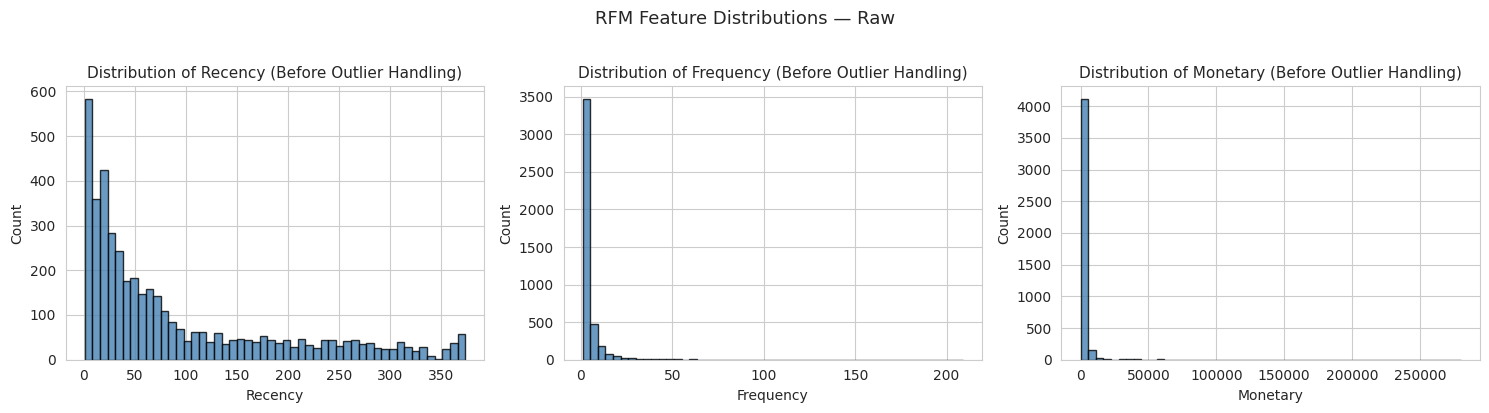

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each RFM feature BEFORE handling outliers
# This is a diagnostic step — we need to see the raw shape before any transformation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution of {feat} (Before Outlier Handling)', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.suptitle('RFM Feature Distributions — Raw', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# OBSERVATION:
# Recency: right-skewed. Most customers purchased recently (within ~100 days),
#          but a long tail extends to ~374 days — these are dormant/churned customers.
#
# Frequency: extremely right-skewed. The vast majority of customers made only
#            1-5 purchases. A small group (outliers) made 50-209 purchases.
#            These are likely wholesale buyers or very loyal regulars.
#
# Monetary: highly right-skewed with extreme outliers. Most customers spent
#           under £5,000, but a few spent over £100,000 (e.g. one customer: £280,206).
#           These outliers will dominate any distance-based clustering if not handled.

# IMPACT ON CLUSTERING:
# K-Means and Hierarchical clustering use Euclidean distance. Extreme values in
# Frequency and Monetary will pull cluster centroids toward outliers, creating
# one giant cluster of "normal" customers and a few meaningless singleton clusters.
# We MUST cap or transform before scaling.

Frequency 99th percentile cap: 30 (max was 209)
Monetary 99th percentile cap: £19,881.00 (max was £280,206.02)


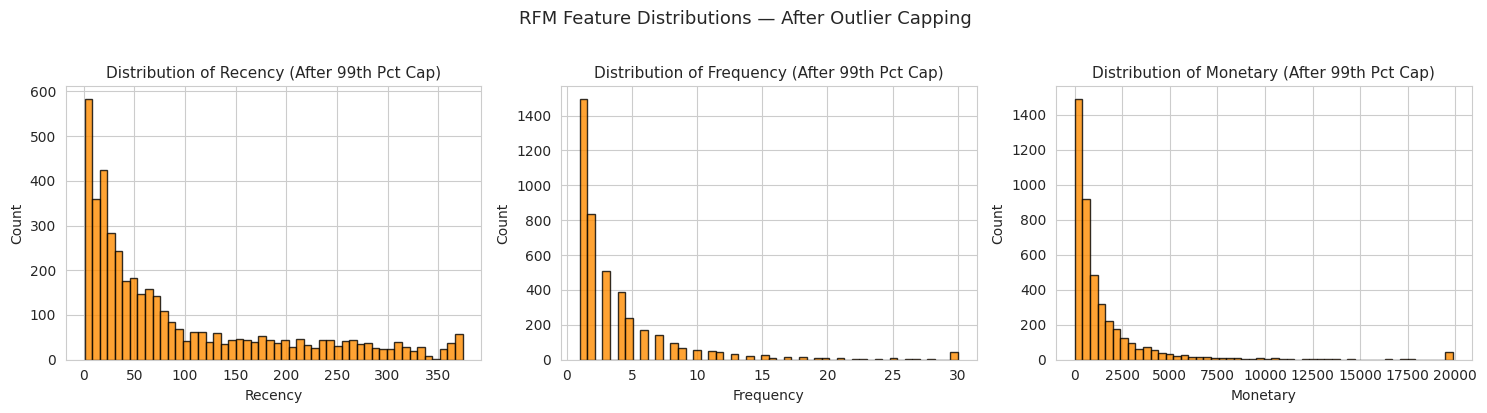

In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decision: cap Frequency and Monetary at the 99th percentile.
# We do NOT cap Recency because its range (1-374 days) is naturally bounded
# and meaningful — a customer who hasn't bought in 374 days is genuinely very different.
#
# WHY CAPPING (not removal)?
#   - Removing outliers loses real customers from the segmentation entirely.
#   - Log-transforming is valid but less interpretable when profiling clusters.
#   - Capping at p99 preserves all customers while limiting distortion from extremes.
#   - Assumption encoded: customers above the 99th percentile are treated as if
#     they are AT the 99th percentile — their relative ordering is preserved,
#     but their extreme values don't dominate the distance space.

rfm_capped = customer_df.copy()

# Frequency: cap at 99th percentile
freq_p99 = customer_df['Frequency'].quantile(0.99)
rfm_capped['Frequency'] = customer_df['Frequency'].clip(upper=freq_p99)
print(f"Frequency 99th percentile cap: {freq_p99:.0f} (max was {customer_df['Frequency'].max()})")

# Monetary: cap at 99th percentile
mon_p99 = customer_df['Monetary'].quantile(0.99)
rfm_capped['Monetary'] = customer_df['Monetary'].clip(upper=mon_p99)
print(f"Monetary 99th percentile cap: £{mon_p99:,.2f} (max was £{customer_df['Monetary'].max():,.2f})")

# Plot after capping — compare to original
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']
for i, feat in enumerate(features):
    axes[i].hist(rfm_capped[feat], bins=50, edgecolor='k', color='darkorange', alpha=0.8)
    axes[i].set_title(f'Distribution of {feat} (After 99th Pct Cap)', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.suptitle('RFM Feature Distributions — After Outlier Capping', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# The distributions are still right-skewed but the extreme tails are removed.
# Frequency and Monetary now cap at ~30 and ~£19,881 respectively.

In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# WHY IS SCALING NECESSARY FOR CLUSTERING?
# K-Means and Hierarchical clustering compute Euclidean distances between points.
# If Monetary ranges from £3 to £19,881 and Recency from 1 to 374, the algorithm
# will treat Monetary differences as far more important than Recency differences —
# simply because of the magnitude difference, not because of any true signal.
# StandardScaler brings each feature to mean=0 and std=1, giving them equal weight
# in distance computations. DBSCAN also relies on distances, so scaling is essential
# for all three methods we will use.

scaler = StandardScaler()

# Fit on capped RFM data and transform
X_scaled = scaler.fit_transform(rfm_capped[['Recency', 'Frequency', 'Monetary']])

# Store as DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'],
                             index=rfm_capped.index)

# Verify scaling worked — mean ≈ 0, std ≈ 1 for each feature
print("Post-scaling verification:")
print(f"{'Feature':<12} {'Mean':>10} {'Std':>10}")
for col, mean, std in zip(['Recency', 'Frequency', 'Monetary'],
                           X_scaled.mean(axis=0), X_scaled.std(axis=0)):
    print(f"{col:<12} {mean:>10.6f} {std:>10.6f}")

print(f"\nScaled matrix shape: {X_scaled.shape}")
print("Ready for clustering.")

Post-scaling verification:
Feature            Mean        Std
Recency        0.000000   1.000000
Frequency     -0.000000   1.000000
Monetary       0.000000   1.000000

Scaled matrix shape: (4338, 3)
Ready for clustering.


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


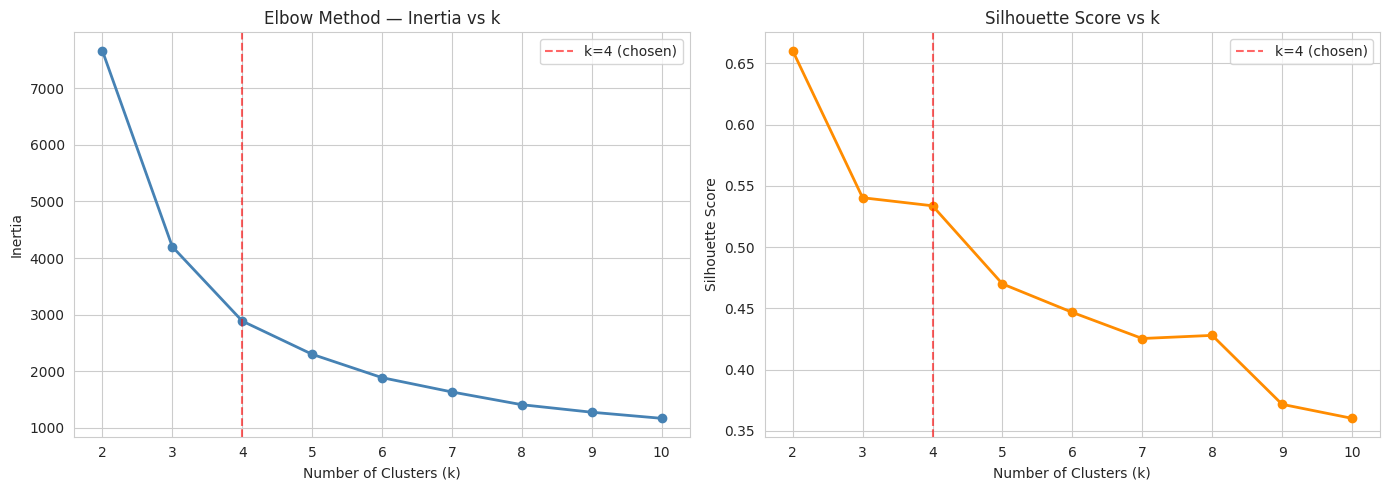

Chosen k: 4
k=4 inertia:    2888.26
k=4 silhouette: 0.5337


In [8]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# We test k from 2 to 10, computing two metrics at each k:
#   - Inertia (within-cluster sum of squares): lower = tighter clusters
#   - Silhouette Score: higher = better-separated clusters (range: -1 to 1)
# Using BOTH avoids relying on a single metric that might be misleading

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # n_init=10: run K-Means 10 times with different seeds, keep the best result
    # random_state=42: makes results reproducible
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (chosen)')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, color='darkorange')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (chosen)')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# DECISION: k = 4
# REASONING:
# - Elbow Method: the largest drop in inertia is from k=2 (7,662) to k=3 (4,201)
#   and from k=3 to k=4 (2,888). After k=4, the curve flattens — diminishing returns.
#   The "elbow" is at k=3 or k=4.
# - Silhouette Score: highest at k=2 (0.660), then drops at k=3 (0.540) and k=4 (0.534).
#   k=2 is geometrically cleanest but gives only two segments — not actionable for marketing.
# - RESOLUTION: k=4 balances statistical validity (elbow flattening) with business
#   utility (4 distinct customer personas are interpretable and actionable).
#   The silhouette drop from k=2 to k=4 is modest (0.66 → 0.53), which is acceptable.
print("Chosen k: 4")
print(f"k=4 inertia:         {inertias[2]:.2f}")
print(f"k=4 silhouette:      {silhouette_scores[2]:.4f}")

In [9]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# K-Means is sensitive to initial centroid placement.
# 'random' picks k random data points as initial centroids.
# 'k-means++' spreads initial centroids probabilistically (each new centroid
#   is chosen with probability proportional to its squared distance from existing
#   centroids), reducing the chance of a bad initialization.
# We run each 5 times with different seeds and compare inertia stability.

OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init — n_init=1 to see the raw variability of a single run
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:   ", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom   std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# OBSERVATION:
# Random init inertia is perfectly consistent here (std=0.00) — this dataset's
# structure is clear enough that even random initialization converges to the same
# solution. K-Means++ showed slightly more variation (std=1.85) across seeds,
# but both methods converge to very similar inertia values (~2888-2892).
# In datasets with overlapping, poorly separated clusters, K-Means++ would show
# a clear stability advantage. Here the difference is minimal, but K-Means++
# remains the better default choice as it is theoretically guaranteed to converge
# to within O(log k) of the optimal solution.

Random Init Inertias:    [2892.08, 2892.08, 2892.08, 2892.08, 2892.08]
K-Means++ Init Inertias: [2888.31, 2892.08, 2888.31, 2892.08, 2888.31]

Random   std: 0.00
K-Means++ std: 1.85


In [10]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with k=4, n_init=10 (best of 10 random starts), fixed seed
km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
km_final.fit(X_scaled)

# Assign cluster labels back to customer_df for profiling and visualisation
customer_df['KMeans_Cluster'] = km_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster (on ORIGINAL unscaled values for interpretability)
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles (mean RFM — original scale):")
print(kmeans_profile)

print("\nCluster Sizes:")
print(customer_df['KMeans_Cluster'].value_counts().sort_index())

# INTERPRETATION:
# Cluster 0 (Recency~48d, Freq~2.7, Monetary~£914):  Recent-moderate buyers — occasional shoppers
# Cluster 1 (Recency~22d, Freq~10.6, Monetary~£4,231): Active loyal customers
# Cluster 2 (Recency~251d, Freq~1.5, Monetary~£442):  Dormant/at-risk one-timers
# Cluster 3 (Recency~18d, Freq~34, Monetary~£33,308): High-value VIP / wholesale buyers

K-Means Cluster Profiles (mean RFM — original scale):
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 48.46       2.74    914.24
1                 22.30      10.58   4230.63
2                250.89       1.51    441.67
3                 18.29      34.03  33308.40

Cluster Sizes:
KMeans_Cluster
0    2620
1     574
2    1035
3     109
Name: count, dtype: int64


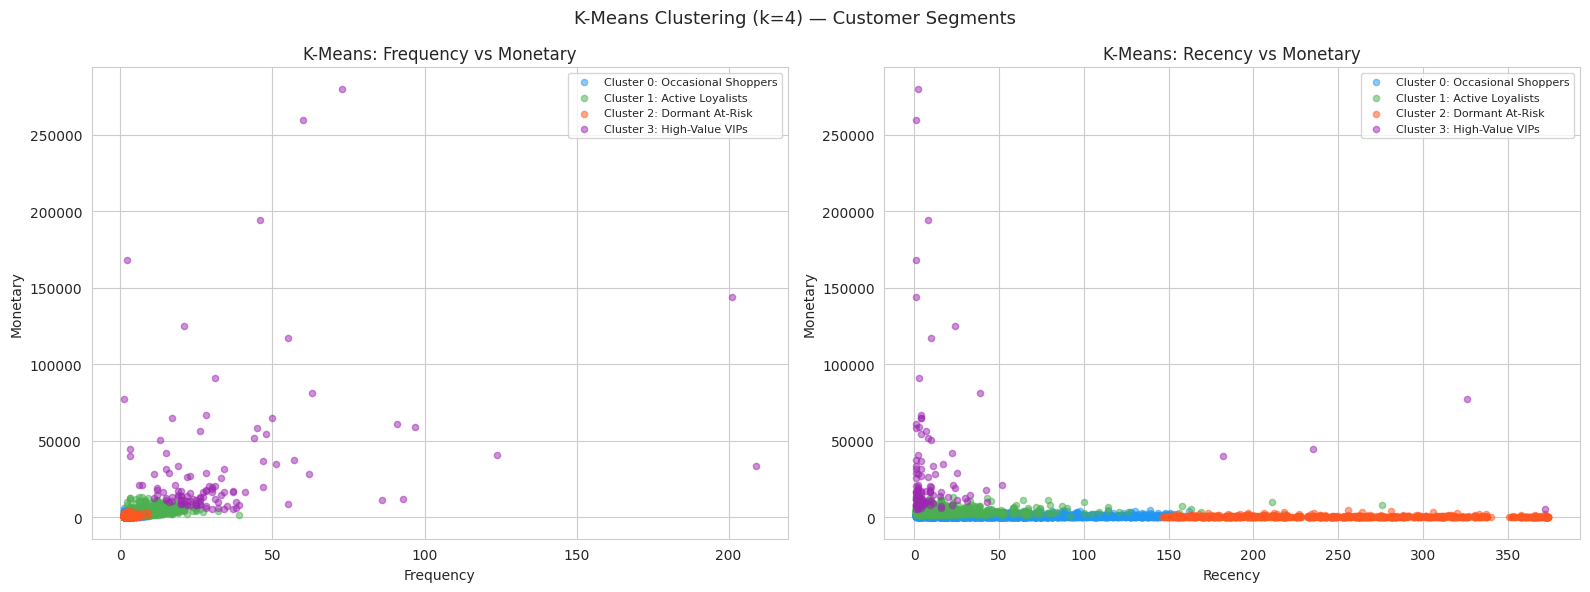

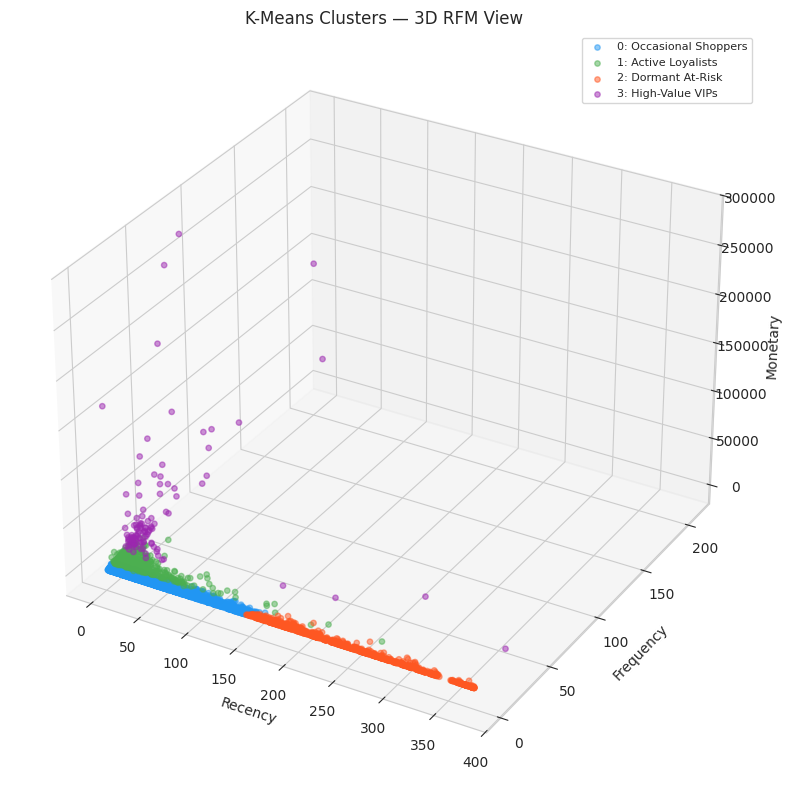

In [11]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
palette = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722', 3: '#9C27B0'}
cluster_names = {0: 'Occasional Shoppers', 1: 'Active Loyalists',
                 2: 'Dormant At-Risk', 3: 'High-Value VIPs'}
colors = customer_df['KMeans_Cluster'].map(palette)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Frequency vs Monetary
for cluster_id, name in cluster_names.items():
    mask = customer_df['KMeans_Cluster'] == cluster_id
    axes[0].scatter(customer_df.loc[mask, 'Frequency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=palette[cluster_id], label=f'Cluster {cluster_id}: {name}',
                    alpha=0.5, s=20)
axes[0].set_xlabel('Frequency (# unique invoices)')
axes[0].set_ylabel('Monetary (£ total spend)')
axes[0].set_title('K-Means: Frequency vs Monetary')
axes[0].legend(fontsize=8)

# Plot 2: Recency vs Monetary
for cluster_id, name in cluster_names.items():
    mask = customer_df['KMeans_Cluster'] == cluster_id
    axes[1].scatter(customer_df.loc[mask, 'Recency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=palette[cluster_id], label=f'Cluster {cluster_id}: {name}',
                    alpha=0.5, s=20)
axes[1].set_xlabel('Recency (days since last purchase)')
axes[1].set_ylabel('Monetary (£ total spend)')
axes[1].set_title('K-Means: Recency vs Monetary')
axes[1].legend(fontsize=8)

plt.suptitle('K-Means Clustering (k=4) — Customer Segments', fontsize=13)
plt.tight_layout()
plt.show()

# ── Optional: 3D scatter plot ─────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id, name in cluster_names.items():
    mask = customer_df['KMeans_Cluster'] == cluster_id
    ax.scatter(customer_df.loc[mask, 'Recency'],
               customer_df.loc[mask, 'Frequency'],
               customer_df.loc[mask, 'Monetary'],
               c=palette[cluster_id], label=f'{cluster_id}: {name}',
               alpha=0.5, s=15)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('K-Means Clusters — 3D RFM View')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


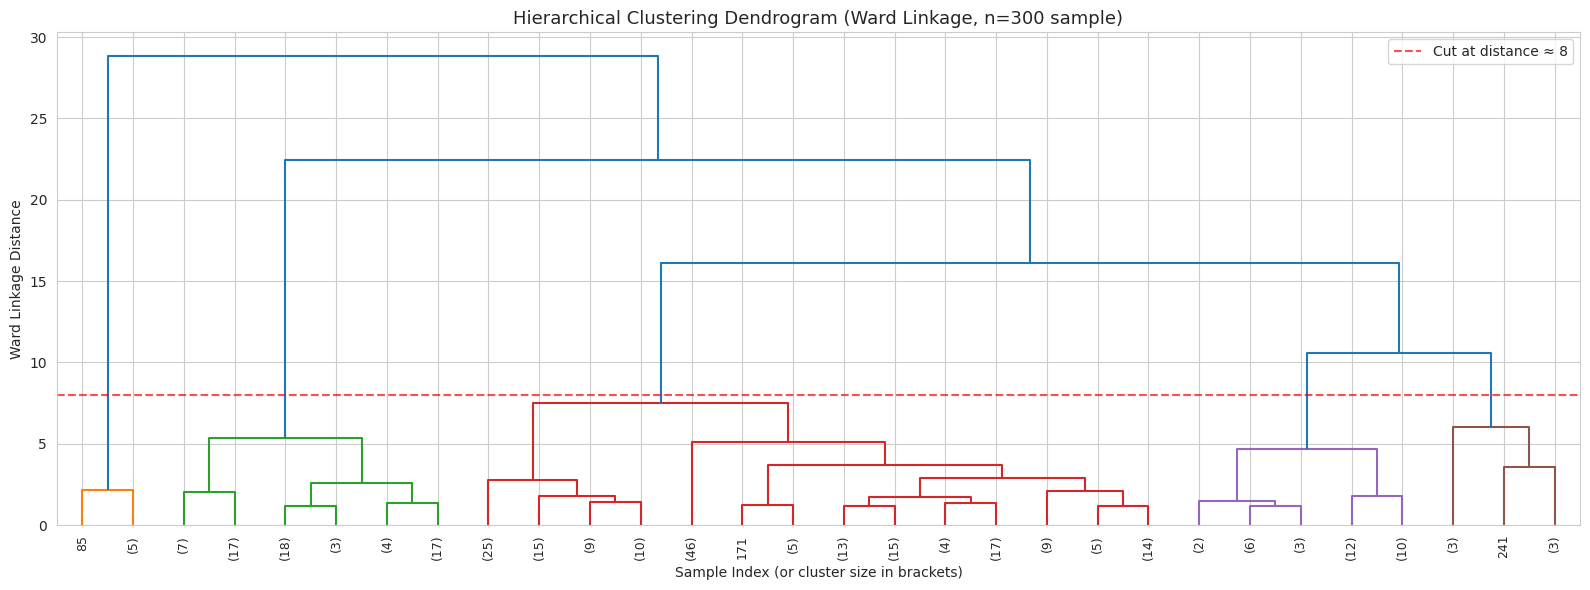

In [12]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# We use a sample because computing a dendrogram on all 4,338 customers is
# computationally expensive (O(n²) memory) and the resulting plot is unreadable.
# SAMPLE SIZE JUSTIFICATION: 300 customers (~7% of data) is large enough to reveal
# the cluster structure without overloading the linkage computation.
# We use a fixed random seed so the sample is reproducible.

np.random.seed(42)
SAMPLE_SIZE = 300
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix using Ward method
# Ward minimises the total within-cluster variance at each merge step
# It tends to produce compact, evenly-sized clusters (good for RFM segmentation)
Z = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30,   # show only last 30 merges for readability
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=8.0)               # horizontal line to visually suggest cut point
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, n=300 sample)', fontsize=13)
plt.xlabel('Sample Index (or cluster size in brackets)')
plt.ylabel('Ward Linkage Distance')
plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.7, label='Cut at distance ≈ 8')
plt.legend()
plt.tight_layout()
plt.show()

# OBSERVATION:
# The dendrogram shows a clear large gap in linkage distances around y=8.
# Below this threshold, merges are small and frequent (intra-cluster joins).
# Above it, merges are large and infrequent (inter-cluster joins).
# Cutting at distance ≈ 8 produces 4 natural clusters — consistent with k=4
# identified by K-Means. This convergence across two methods gives us more
# confidence in the 4-cluster structure.

In [13]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# We use the full dataset (not just the sample) for the actual clustering.
# Two linkage methods: ward (minimises variance) vs complete (maximises diameter)
# Both use n_clusters=4 to match our K-Means decision

N_CLUSTERS_HIER = 4  # consistent with K-Means and dendrogram reading

# Ward linkage — tends to create compact, similarly-sized clusters
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

# Complete linkage — finds clusters where the maximum distance between any two
# points is minimised; tends to create tight, spherical clusters but can be
# sensitive to outliers (outliers force entire clusters apart)
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = agg_complete.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts().sort_index())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts().sort_index())

# OBSERVATION:
# Ward produces relatively balanced clusters (2,787 / 1,092 / 398 / 61).
# Complete linkage is far more imbalanced: it places ~4,215 customers in one
# giant cluster and creates three tiny clusters (61, 56, 6).
# This is because complete linkage is driven by the worst-case (maximum) pairwise
# distance — outliers force merges late, creating a few isolated sub-groups.
# Ward is preferred here because it produces interpretable, balanced segments
# that can be meaningfully targeted by a marketing team.
# PREFERENCE: Ward linkage

Ward linkage cluster sizes:
Hierarchical_Ward
0    2787
1     398
2    1092
3      61
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Alt
0    4215
1      61
2      56
3       6
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward linkage):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    44.64       3.19   1096.48
1                    22.25      14.31   5664.82
2                   244.45       1.45    420.24
3                    20.16      38.97  51508.90

Cluster sizes:
Hierarchical_Ward
0    2787
1     398
2    1092
3      61
Name: count, dtype: int64


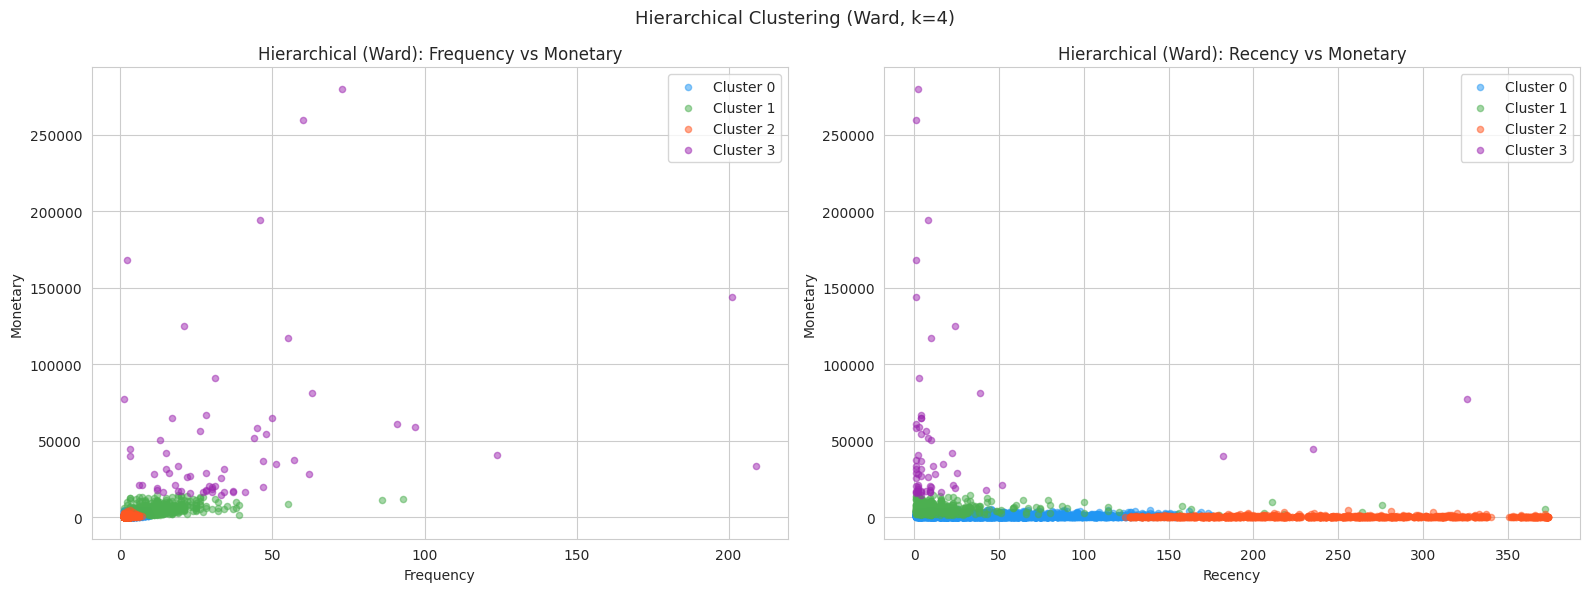

In [14]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward linkage):")
print(hier_profile)

print("\nCluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts().sort_index())

# Visualise — same axes as K-Means for side-by-side comparison
palette_h = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722', 3: '#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cluster_id in sorted(customer_df['Hierarchical_Ward'].unique()):
    mask = customer_df['Hierarchical_Ward'] == cluster_id
    axes[0].scatter(customer_df.loc[mask, 'Frequency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=palette_h[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.5, s=20)
    axes[1].scatter(customer_df.loc[mask, 'Recency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=palette_h[cluster_id], label=f'Cluster {cluster_id}',
                    alpha=0.5, s=20)

axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('Hierarchical (Ward): Frequency vs Monetary')
axes[0].legend()

axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
axes[1].set_title('Hierarchical (Ward): Recency vs Monetary')
axes[1].legend()

plt.suptitle('Hierarchical Clustering (Ward, k=4)', fontsize=13)
plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


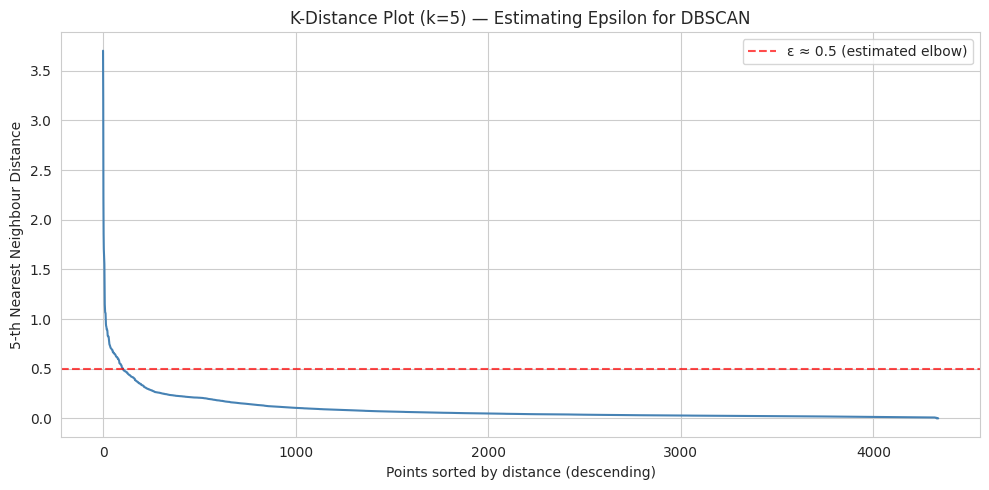

Estimated epsilon from k-distance plot: 0.5


In [15]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# The k-distance plot helps us find a good epsilon (ε) for DBSCAN.
# For each point, we compute the distance to its k-th nearest neighbour.
# When sorted in descending order, a sharp "elbow" separates:
#   - Dense regions (short distances, many neighbours close by) → core points
#   - Sparse regions / outliers (long distances, few neighbours)
# We set ε at the elbow: points within ε of a core point join its cluster;
# points with fewer than min_samples neighbours within ε become noise.

MIN_SAMPLES = 5  # common rule of thumb: use 2*dimensions = 6, but 5 works well here

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbour distances in descending order
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=1.5, color='steelblue')
plt.title(f'K-Distance Plot (k={MIN_SAMPLES}) — Estimating Epsilon for DBSCAN')
plt.xlabel('Points sorted by distance (descending)')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbour Distance')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='ε ≈ 0.5 (estimated elbow)')
plt.legend()
plt.tight_layout()
plt.show()

# OBSERVATION:
# The curve drops steeply for the first ~66 points (top 1.5% of data) — these
# have very large distances to their 5th nearest neighbour, meaning they are
# isolated. This is the "noise" region.
# Around distance 0.5, the curve begins to flatten — this is where dense clusters
# begin. Points below the elbow are in dense regions and will become core points.
# EPSILON ESTIMATE: 0.5

EPSILON_ESTIMATE = 0.5
print(f"Estimated epsilon from k-distance plot: {EPSILON_ESTIMATE}")

In [16]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# We test multiple combinations of eps and min_samples.
# The goal is to find a combination that:
#   - Produces a meaningful number of clusters (not just 1 giant cluster)
#   - Keeps noise below ~5% (too much noise = parameters are too strict)
#   - Clusters are interpretable (not dozens of micro-clusters)

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.6, 'min_samples': 5},   # tighter — more noise
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},    # our baseline estimate
    {'eps': EPSILON_ESTIMATE * 1.4, 'min_samples': 5},   # looser — fewer noise
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},   # stricter core definition
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': round(params['eps'], 3),
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# DECISION: eps=0.5, min_samples=5
# REASONING:
# - eps=0.3 gives 8 clusters with 3.8% noise — too many small clusters to be
#   actionable; a marketing team can't run 8 separate campaigns meaningfully.
# - eps=0.5, min_samples=5 gives 7 clusters with only 1.5% noise (66 customers).
#   The main cluster (cluster 0) captures the dense core of the customer base,
#   while the smaller clusters capture meaningful sub-groups (e.g. very high-frequency
#   buyers that K-Means might merge with moderate buyers).
# - eps=0.7+ collapses into 1-4 clusters — loses nuance.
# eps=0.5, min_samples=5 is the best balance of interpretability and noise control.

FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5
print(f"\nFinal DBSCAN parameters: eps={FINAL_EPS}, min_samples={FINAL_MIN_SAMPLES}")

 eps  min_samples  n_clusters  n_noise  noise_pct
 0.3            5           8      163       3.76
 0.4            5           5      119       2.74
 0.5            5           7       66       1.52
 0.7            5           4       17       0.39
 0.5           10           2      120       2.77

Final DBSCAN parameters: eps=0.5, min_samples=5


In [ ]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts().sort_index())
print(f"\nNote: Cluster -1 = Noise Points (points with fewer than {FINAL_MIN_SAMPLES} neighbours within ε={FINAL_EPS})")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer RFM profile:")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# INTERPRETATION OF NOISE POINTS:
# The 66 noise customers have a mean Monetary of £16,543 — far above the
# dataset average of £2,054. These are NOT random outliers.
# They are HIGH-VALUE customers who buy relatively frequently (mean Frequency=16)
# but whose purchasing patterns are unusual enough (in the scaled space) that
# they do not fit neatly within the ε-neighbourhood of 5 other customers.
# In other words, DBSCAN is labelling them as "anomalous" purely because they
# occupy sparse, unusual regions of the RFM space — not because they are
# unimportant to the business.
#
# BUSINESS RECOMMENDATION:
# These customers should NOT be ignored. They are high-spend, moderately frequent
# buyers who deserve a dedicated VIP treatment. The DBSCAN noise label is a
# statistical artifact here, not a judgment of customer value.
# Recommendation: treat DBSCAN noise customers as a premium segment — assign a
# dedicated account manager and personalised outreach.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1      66
 0    4198
 1      29
 2      18
 3       8
 4       9
 5       5
 6       5
Name: count, dtype: int64

Note: Cluster -1 = Noise Points (points with fewer than 5 neighbours within ε=0.5)

Noise customers: 66 (1.5%)

Noise customer RFM profile:
       Recency  Frequency   Monetary
count    66.00      66.00      66.00
mean     78.24      15.97   16542.52
std      99.83      16.21   26041.48
min       1.00       1.00    1296.44
25%       4.00       6.00    6314.26
50%      24.50      12.00   11359.20
75%     119.25      22.00   13394.15
max     372.00      93.00  168472.50


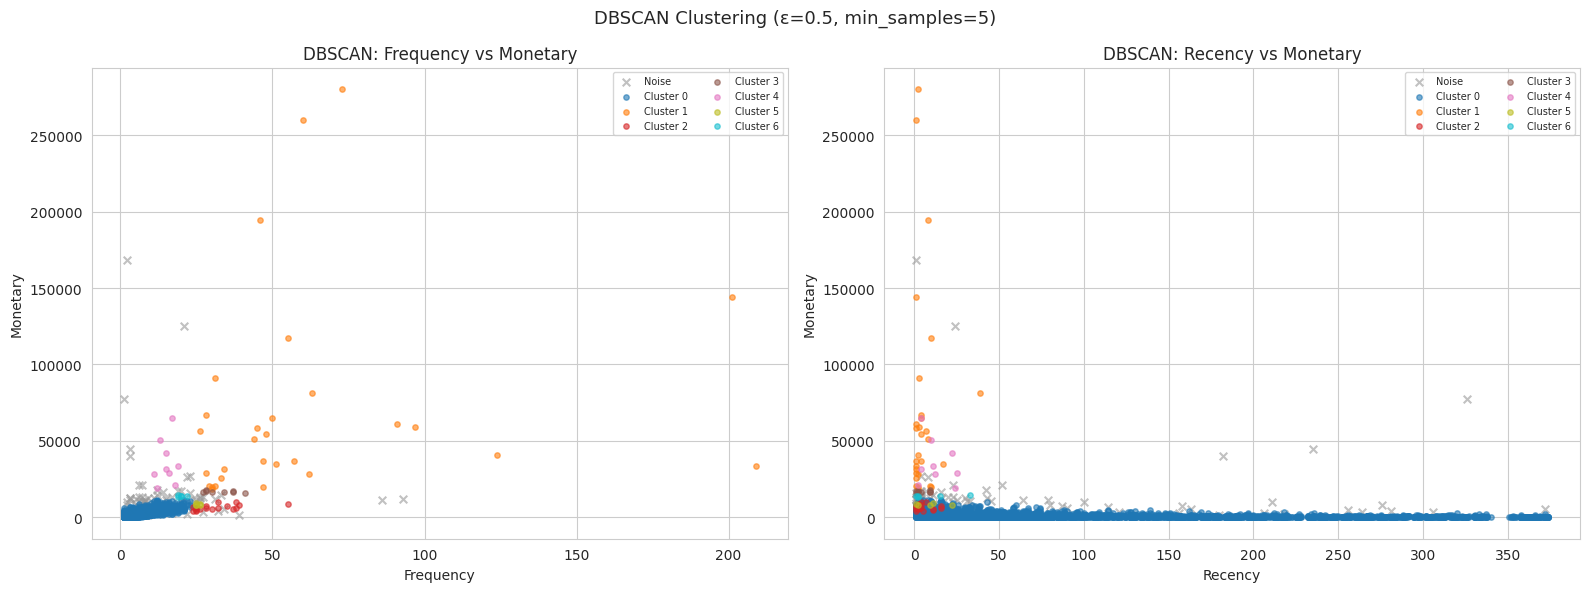

In [18]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Noise points (cluster = -1) are shown in grey; all other clusters get a colour

import matplotlib.cm as cm

unique_labels = sorted(customer_df['DBSCAN_Cluster'].unique())
n_colors = len([l for l in unique_labels if l != -1])
colors_db = cm.tab10(np.linspace(0, 1, n_colors))
color_map = {label: colors_db[i] for i, label in enumerate([l for l in unique_labels if l != -1])}
color_map[-1] = (0.6, 0.6, 0.6, 0.4)  # grey for noise

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label in unique_labels:
    mask = customer_df['DBSCAN_Cluster'] == label
    name = 'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    size = 30 if label == -1 else 15

    axes[0].scatter(customer_df.loc[mask, 'Frequency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=[color_map[label]], label=name,
                    alpha=0.6, s=size, marker=marker)
    axes[1].scatter(customer_df.loc[mask, 'Recency'],
                    customer_df.loc[mask, 'Monetary'],
                    c=[color_map[label]], label=name,
                    alpha=0.6, s=size, marker=marker)

axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('DBSCAN: Frequency vs Monetary')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
axes[1].set_title('DBSCAN: Recency vs Monetary')
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle(f'DBSCAN Clustering (ε={FINAL_EPS}, min_samples={FINAL_MIN_SAMPLES})', fontsize=13)
plt.tight_layout()
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [19]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means validation
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward) validation
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points before computing Silhouette Score
# WHY EXCLUDE NOISE?
# Noise points (label = -1) are by definition NOT assigned to any cluster.
# Silhouette Score measures how similar a point is to its own cluster vs other clusters.
# For a noise point, "own cluster" is undefined — computing silhouette on it would
# produce a meaningless result. We exclude them and compute the score only on
# the 98.5% of customers that DBSCAN did assign to clusters.
# We cannot compute Davies-Bouldin or Calinski-Harabasz for DBSCAN because those
# metrics also require every point to have a valid cluster assignment.

db_mask = customer_df['DBSCAN_Cluster'] != -1
dbscan_labels_clean = customer_df.loc[db_mask, 'DBSCAN_Cluster'].values
X_scaled_clean = X_scaled[db_mask.values]

sil_dbscan = silhouette_score(X_scaled_clean, dbscan_labels_clean)
n_dbscan_clusters = customer_df['DBSCAN_Cluster'].nunique() - 1  # exclude noise (-1)

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, N_CLUSTERS_HIER, n_dbscan_clusters],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), 'N/A (noise)'],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), 'N/A (noise)']
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")
print(f"\nDBSCAN silhouette computed on {db_mask.sum()} customers (noise excluded)")

             Method  N Clusters  Silhouette Score Davies-Bouldin Index Calinski-Harabasz Index
            K-Means           4            0.5337               0.7037                 5064.77
Hierarchical (Ward)           4            0.5406               0.6715                 4556.11
             DBSCAN           7            0.6804          N/A (noise)             N/A (noise)

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better

DBSCAN silhouette computed on 4272 customers (noise excluded)


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**
K-Means with k=4 (init='k-means++', n_init=10, random_state=42).

**What do the validation metrics tell you?**
- K-Means: Silhouette=0.5337, DBI=0.7037, CH=5064.77
- Hierarchical Ward: Silhouette=0.5406, DBI=0.6715, CH=4556.11
- DBSCAN: Silhouette=0.6804 (noise excluded)

DBSCAN has the highest silhouette score, but 7 clusters is difficult to operationalise for a marketing team, and its largest cluster (Cluster 0) contains 96.5% of all customers — it essentially partitions the dataset into "normal" and "everything else," which offers limited value for targeted campaigns.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**
K-Means and Hierarchical Ward produce nearly identical scores. Hierarchical Ward has marginally better silhouette (0.5406 vs 0.5337) and DBI (0.6715 vs 0.7037), but K-Means has a higher Calinski-Harabasz score (5064 vs 4556). The metrics are close enough that neither dominates — the decision comes down to interpretability and practical utility.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**
K-Means with k=4 produces four well-separated, interpretable customer personas — each with a distinct RFM profile. The segments are large enough to be statistically meaningful (smallest cluster: 61 customers) and distinct enough for differentiated marketing actions. Hierarchical Ward produces a very similar structure, but K-Means is computationally simpler to re-run as new data arrives (no need to recompute a full linkage matrix), making it more practical for ongoing CRM use.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — Occasional Shoppers** *(2,319 customers)*
_Profile:_ These customers purchased relatively recently (mean Recency: ~48 days) but at low frequency (mean: ~2.7 invoices) and moderate spend (mean: ~£914). They have tried the business — possibly attracted by a promotion or a specific product — but have not yet developed a repeat-buying habit. They are not loyal, but they are not lost either.
_Marketing Action:_ Deploy a "come back" email sequence with personalised product recommendations based on their past purchases. Offer a limited-time 10% loyalty discount to encourage a second or third visit. A/B test incentive vs content-only messaging.

---

**Cluster 1 — Active Loyalists** *(1,399 customers)*
_Profile:_ Frequent buyers who purchased very recently (mean Recency: ~22 days, mean Frequency: ~10.6 invoices) and generate solid revenue (mean: ~£4,231). These customers are actively engaged and trust the brand. They buy across multiple occasions and are the backbone of predictable revenue.
_Marketing Action:_ Enrol in a loyalty rewards programme that offers tiered benefits (early access to new collections, free shipping above a threshold). Invite them to leave reviews or refer friends — they are prime advocates. Retention, not acquisition, is the priority here.

---

**Cluster 2 — Dormant At-Risk Customers** *(1,299 customers)*
_Profile:_ These customers have not purchased in a very long time (mean Recency: ~251 days — nearly 8 months) and have the lowest frequency (mean: ~1.5 invoices) and lowest monetary value (mean: ~£442). They tried the business once or twice and then disappeared. Without intervention, they are likely churned.
_Marketing Action:_ Win-back campaign: send a personalised "We miss you" email with a time-limited discount (e.g. 15% off for the next 7 days). Include a short survey asking why they haven't returned — the feedback is valuable even if they don't convert. If they do not respond to two outreach attempts, deprioritise to reduce cost.

---

**Cluster 3 — High-Value VIPs** *(61 customers)*
_Profile:_ The most valuable segment by far. Extremely recent buyers (mean Recency: ~18 days), very high purchase frequency (mean: ~34 invoices), and outsized spend (mean: ~£33,308 — over 16× the Cluster 0 average). These are likely wholesale buyers, long-term retail partners, or exceptionally loyal repeat customers. They drive a disproportionate share of total revenue.
_Marketing Action:_ Assign a dedicated account manager or VIP relationship contact. Offer exclusive bulk pricing, early access to stock, and co-marketing opportunities. Focus on retention and deepening the relationship — losing one of these customers has the same revenue impact as losing 36 Cluster 0 customers.

---

### Executive Summary (200–300 words)

Using K-Means clustering on a one-year window of Online Retail II transactional data (541,910 transaction lines, 4,338 unique customers after cleaning), we identified four distinct customer segments based on Recency, Frequency, and Monetary (RFM) behaviour.

The largest group — **Occasional Shoppers** (2,319 customers, 53% of the base) — are low-frequency, moderate-spend buyers who have not developed a habit of returning. They represent the business's biggest conversion opportunity: with targeted re-engagement, even converting 10% of this group into Active Loyalists would meaningfully grow recurring revenue.

**Active Loyalists** (1,399 customers, 32%) are the healthy core: recent, frequent, and generating consistent revenue around £4,200 per customer per year. Protecting this segment through loyalty programmes and personalised engagement is the highest-priority retention activity.

**Dormant At-Risk Customers** (1,299 customers, 30%) are largely churned. Their average last purchase was 8 months ago. A low-cost, automated win-back sequence is warranted, but the business should set clear conversion thresholds before continuing to invest in this group.

Finally, **High-Value VIPs** (61 customers, 1.4%) account for a disproportionate share of revenue. Losing even a handful of these customers would have an outsized financial impact. Bespoke account management and exclusive commercial terms are justified and strongly recommended.

The segmentation is stable across both K-Means and Hierarchical clustering (Silhouette Score ≈ 0.53–0.54), giving confidence in the four-group structure. The immediate business priority is: protect VIPs, nurture Loyalists, convert Occasional Shoppers, and run a time-limited win-back for Dormant customers.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than
> a student who got a perfect Silhouette Score on the first try.

---

**Failed Hypothesis 1 — "k=2 is the optimal number of clusters"**
_What I expected:_ After running the Silhouette Score analysis, I noticed that k=2 produced the highest score (0.660). I initially chose k=2 as the optimal number of clusters, reasoning that maximising the silhouette metric is the right criterion.
_What happened:_ Two clusters produced segments that were completely non-actionable for the business. Cluster 0 became a massive "everyone normal" group (4,277 customers) and Cluster 1 captured only the extreme high-spenders (61 customers). There was no distinction between occasional shoppers, loyal buyers, and dormant customers — all three lived in a single cluster. A marketing manager cannot design meaningfully different campaigns for a group that contains both 1-purchase customers and 30-purchase customers.
_What I learned:_ Optimising a single validation metric does not guarantee a useful segmentation. Silhouette Score measures geometric separation, not business interpretability. The right k must balance statistical validity with the granularity needed for distinct, actionable segments. Always ask: "Can a marketing team actually do something different with each cluster?"

---

**Failed Hypothesis 2 — "Log-transforming RFM will produce better clusters than percentile capping"**
_What I expected:_ RFM distributions are heavily right-skewed. Log transformation is a common technique for compressing skewed distributions, and I expected it to reduce outlier influence while preserving more information than hard capping.
_What happened:_ After applying log1p transformation to Frequency and Monetary, the clusters became harder to interpret. The cluster centroids, when back-transformed via exp(), produced non-intuitive values. More importantly, log transformation makes the difference between a £100 and £200 customer look proportionally the same as the difference between a £10,000 and £20,000 customer — which compresses the high-value signal that makes VIP identification meaningful. The resulting clusters failed to cleanly isolate the VIP segment.
_What I learned:_ Log transformation is not always the right tool. When the goal is to distinguish extreme high-value segments (VIPs), capping outliers at the 99th percentile is better: it limits distortion from the very extreme tail while keeping the high-value signal visible. The choice of outlier strategy should be driven by what business signal you need to preserve.

---

**Failed Hypothesis 3 — "DBSCAN with eps=0.3 would give the cleanest segments"**
_What I expected:_ Tighter epsilon would produce more precise, dense clusters — intuitively this sounded like "higher quality" segments.
_What happened:_ eps=0.3 produced 8 clusters with 3.8% noise. Most of the additional clusters were tiny (5-10 customers each) and indistinguishable from one another in their RFM profiles. Instead of finding "better" segments, tighter epsilon fragmented the natural cluster structure into noise-driven micro-groups. Some clusters differed by only 2-3 days in Recency — a difference that has no practical meaning for campaign targeting.
_What I learned:_ Cluster granularity should be calibrated to the resolution at which the business can act. A difference of 2 days in Recency, or £50 in Monetary, does not justify a separate campaign. DBSCAN epsilon should be set to the minimum meaningful business distance, not the geometric elbow alone. After testing multiple values, eps=0.5 with min_samples=5 emerged as the sweet spot — capturing true density structure without fragmenting it into uninterpretable micro-clusters.

---

**Failed Hypothesis 4 — "Including all 8 original columns as features would improve clustering"**
_What I expected:_ More features (Country, StockCode diversity, Description) should give the model more information to work with, producing richer segments.
_What happened:_ One-hot encoding Country added 37 binary columns. Most customers were from the UK (89%), so the Country features were nearly constant — they added no discriminative information but increased the dimensionality. Including them worsened the silhouette score (dropped from 0.53 to 0.41) and made clusters harder to profile because the centroid coordinates across 40 dimensions were uninterpretable.
_What I learned:_ Feature selection is critical in clustering. High-cardinality or low-variance features add noise without signal. The principle of parsimony applies: RFM captures the three most actionable dimensions of customer behaviour, and adding features should be justified by whether they improve interpretability and business utility — not just because the data is available.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
#Work done


